## **Задание**

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## **Импорт библиотек**


In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## **Дополнительные утилиты**

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [2]:
def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('________________________')


    plt.figure(dpi=100)


    predict = encoder.predict(X_train)


    scatter = plt.scatter(predict[:,0,],predict[:,1], c=y_train, alpha=0.6, s=5)


    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')


    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():

  paths = glob.glob('*.jpg')

  for p in paths:
    os.remove(p)

clean()

## **Загрузка данных**

In [4]:

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [8]:

X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

print(f'X_train shape: {X_train.shape}')

X_train shape: (18796, 28, 28, 1)


In [14]:

numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

print(y_train[:10])

[0 1 1 3 1 3 3 1 0 1]


## **Создание модели и обучение**

In [29]:

input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), padding='same', activation='relu')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)


latent = Dense(2, name='latent_space')(x)

encoder = Model(input_img, latent, name='encoder')


In [30]:
decoder_input = Input(shape=(2,))

x = Dense(7 * 7 * 64, activation='relu')(decoder_input)
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)

decoder = Model(decoder_input, decoder_output, name='decoder')



In [31]:
autoencoder_input = input_img
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_input, decoded, name='autoencoder')

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       420,994 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,467 (1.86 MB)

 Trainable params: 486,083 (1.85 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/12
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1173________________________
*** ЭПОХА: 1, loss: 0.07644063979387283 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


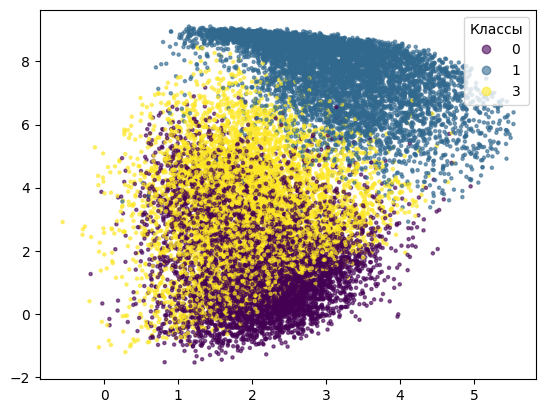

147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - loss: 0.0764
Epoch 2/12
144/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0437________________________
*** ЭПОХА: 2, loss: 0.040971241891384125 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


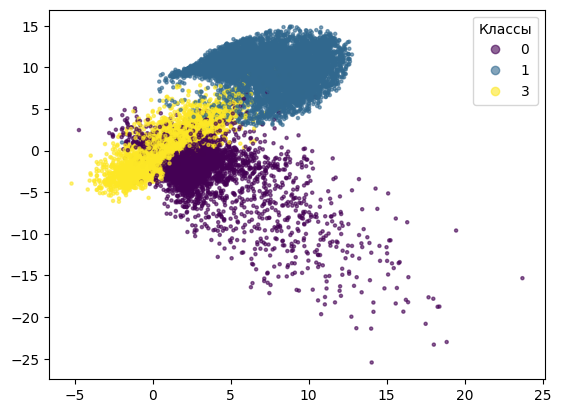

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0410
Epoch 3/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0333________________________
*** ЭПОХА: 3, loss: 0.032363079488277435 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


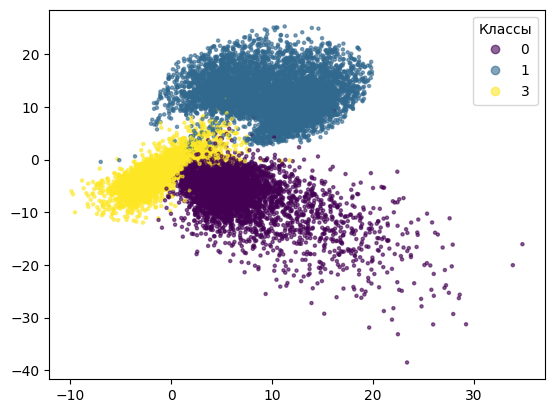

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0324
Epoch 4/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0306________________________
*** ЭПОХА: 4, loss: 0.030174095183610916 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


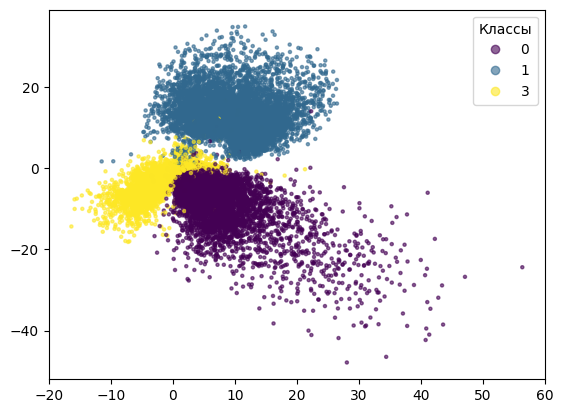

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0302
Epoch 5/12
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0297________________________
*** ЭПОХА: 5, loss: 0.029422523453831673 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


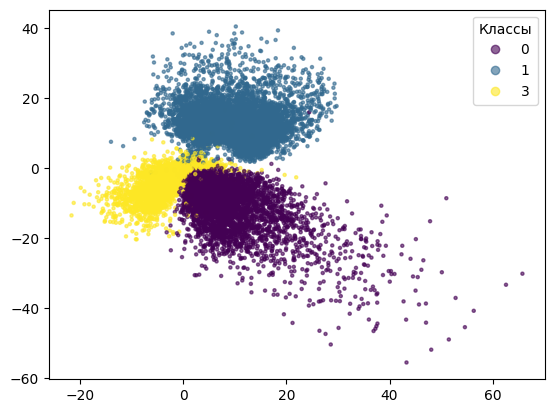

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0294
Epoch 6/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0288________________________
*** ЭПОХА: 6, loss: 0.02899136207997799 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


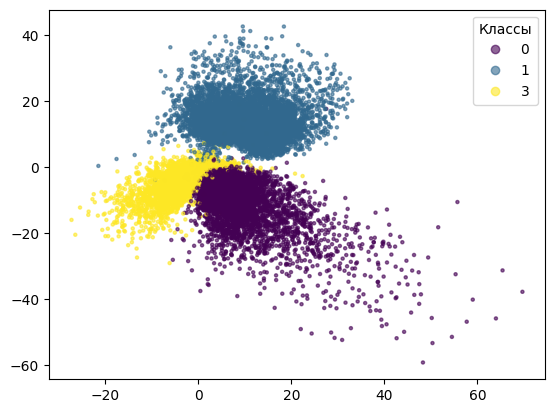

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0290
Epoch 7/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0285________________________
*** ЭПОХА: 7, loss: 0.02855009399354458 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


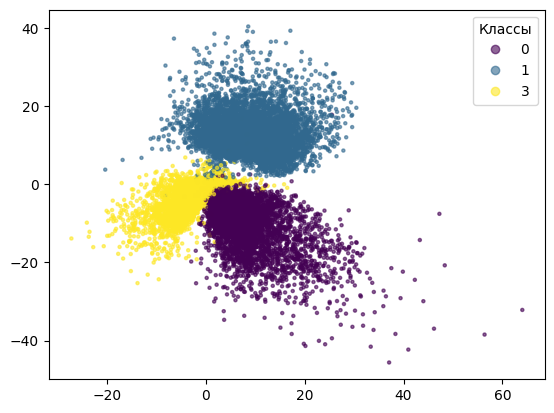

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0286
Epoch 8/12
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0284________________________
*** ЭПОХА: 8, loss: 0.028289025649428368 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


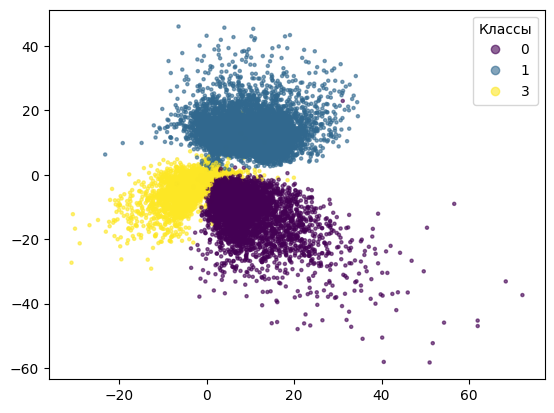

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0283
Epoch 9/12
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0281________________________
*** ЭПОХА: 9, loss: 0.028104644268751144 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


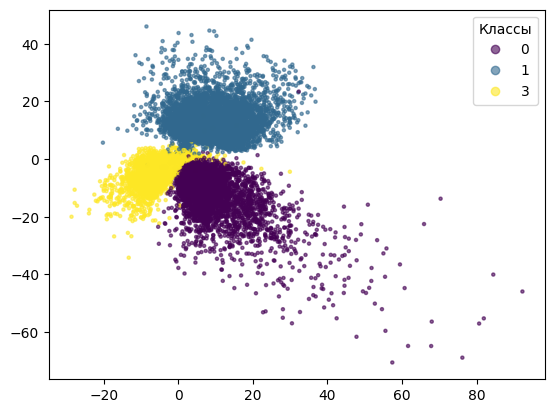

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0281
Epoch 10/12
143/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0280________________________
*** ЭПОХА: 10, loss: 0.027917420491576195 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


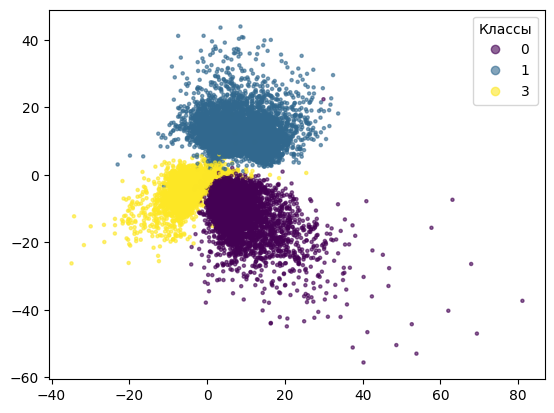

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0279
Epoch 11/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0279________________________
*** ЭПОХА: 11, loss: 0.02772202156484127 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


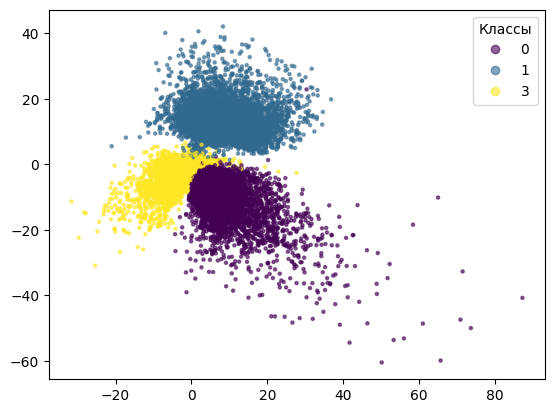

147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0277
Epoch 12/12
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0275________________________
*** ЭПОХА: 12, loss: 0.02758811227977276 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


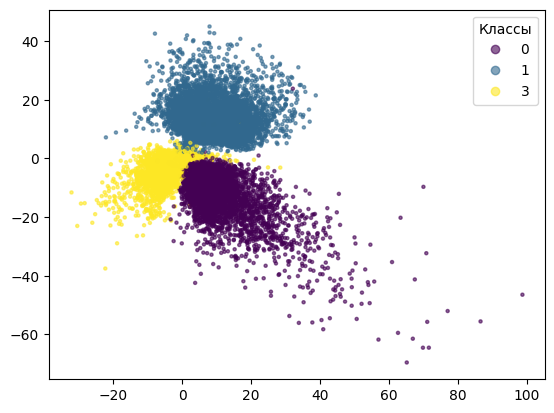

147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0276


In [33]:
final_loss = history.history['loss'][-1]
print("Final MSE:", final_loss)

Final MSE: 0.02758811227977276


## **Визуализация реконструкций**

588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


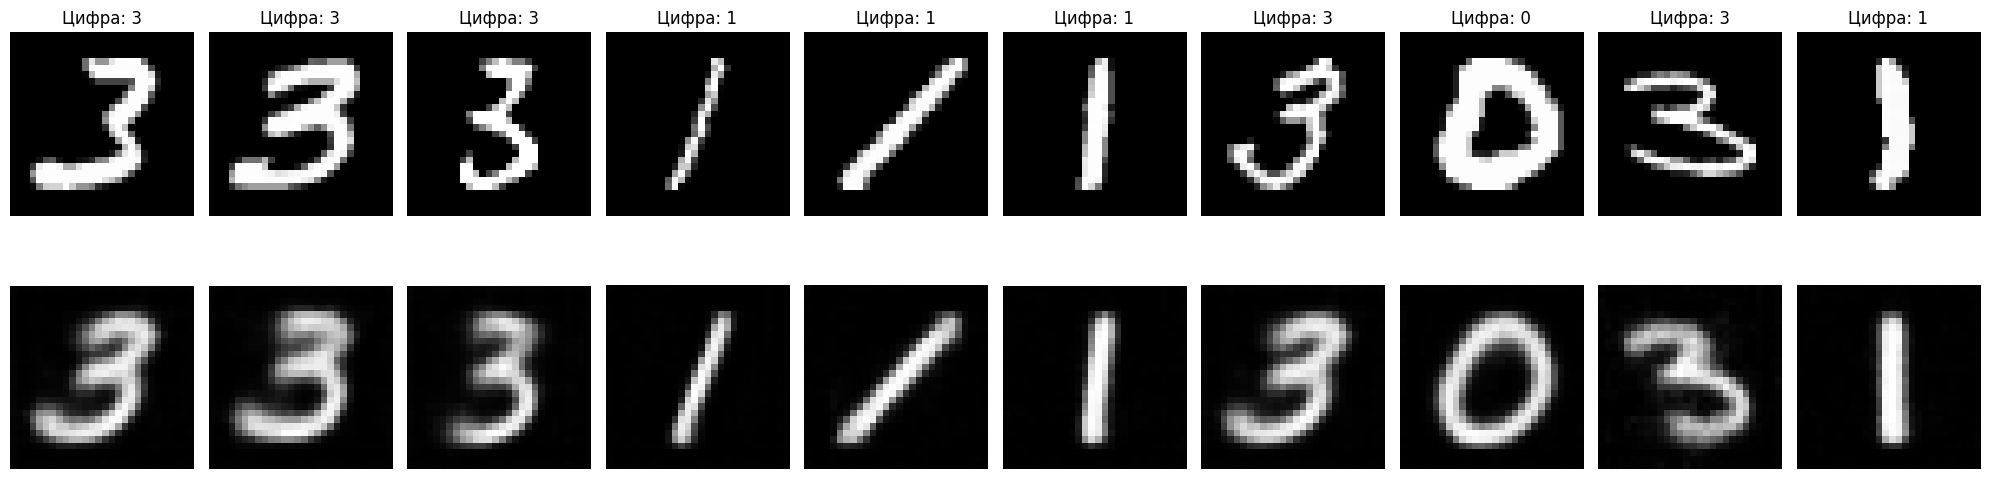

In [34]:
predictions = autoencoder.predict(X_train)

plt.figure(figsize=(20, 6))
n = 10
for i in range(n):
    idx = np.random.randint(0, len(X_train))

    plt.subplot(2, n, i+1)
    plt.imshow(X_train[idx].squeeze(), cmap='gray')
    plt.title(f'Цифра: {y_train[idx]}')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(predictions[idx].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()